<a href="https://colab.research.google.com/github/jcleachi/Avaliacao-Pratica-Modulo-I/blob/main/aula1_machine_learning_industria_aluno.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 1 – Machine Learning Aplicada à Indústria
## Notebook do Aluno

**Nome:** ____________________________________  
**Data:** ____________________________________  

### Objetivo da aula
- compreender o problema industrial;
- ler a base de dados;
- identificar faltantes, duplicatas e possíveis outliers;
- registrar observações que serão usadas no pré-processamento.


## 1. Importação das bibliotecas

Complete a célula abaixo com as bibliotecas que serão usadas.


In [16]:
# Complete:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



## 2. Leitura da base

Complete com o nome do arquivo e carregue o dataset.


In [17]:
# Complete:
arquivo = pd.read_csv('/content/dados_aula1_machine_learning_industria.csv')

df = arquivo
# visualizar dimensões da base
# df.head()
# df.shape
# df.info()
# df.describe().T
df.isna().astype(int).sum().sort_values(ascending=False)
# df.isnull()

,0
vazao_medida_l_min,12
tempo_resposta_ms,11
pressao_linha_bar,10
temperatura_processo_c,10
ph_produto,8
modo_controle,5
operador,5
setpoint_vazao_l_min,0
status_valvula,0
timestamp,0


In [21]:
# Verificar dimensões do dataset
print("Dimensão da base:",df.shape)

Dimensão da base: (188, 15)


## 3. Visualização inicial

Mostre as primeiras linhas da base e registre abaixo o que você percebe.

**Anotações do aluno:**  
- ______________________________________________  
- ______________________________________________  
- ______________________________________________


In [18]:
df.head()


,timestamp,lote_producao,operador,modo_controle,status_valvula,setpoint_vazao_l_min,vazao_medida_l_min,pressao_linha_bar,temperatura_processo_c,abertura_valvula_pct,vibracao_bomba_mm_s,tempo_resposta_ms,ph_produto,densidade_produto_g_cm3,status_instrumentacao
0,2026-01-10 08:00:00,Lote_A,op_b,automatico,normal,121.44,128.08,3.518,95.00,56.97,2.960,220.8,7.09,1.069,estavel
1,2026-01-10 09:00:00,Lote_D,op_c,cascata,normal,126.17,119.32,4.616,43.34,63.26,2.532,402.1,6.99,1.053,inspecao
2,2026-01-10 10:00:00,Lote_B,op_d,manual,intermitente,128.54,129.11,4.118,40.67,63.14,2.182,284.1,6.72,1.021,inspecao
3,2026-01-10 11:00:00,Lote_C,op_a,automatico,intermitente,106.50,102.68,3.547,43.94,64.75,2.772,486.3,6.67,1.093,inspecao
4,2026-01-10 12:00:00,Lote_C,op_a,automatico,normal,101.59,NaN,4.085,102.00,83.82,3.173,283.3,6.66,1.004,estavel


## 4. Tipos de dados

Verifique os tipos das colunas e descreva quais são numéricas e quais são categóricas.

**Anotações do aluno:**  
- Colunas numéricas: ______________________________________________  
- Colunas categóricas: ____________________________________________  


In [19]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                188 non-null    object 
 1   lote_producao            188 non-null    object 
 2   operador                 183 non-null    object 
 3   modo_controle            183 non-null    object 
 4   status_valvula           188 non-null    object 
 5   setpoint_vazao_l_min     188 non-null    float64
 6   vazao_medida_l_min       176 non-null    float64
 7   pressao_linha_bar        178 non-null    float64
 8   temperatura_processo_c   178 non-null    float64
 9   abertura_valvula_pct     188 non-null    float64
 10  vibracao_bomba_mm_s      188 non-null    float64
 11  tempo_resposta_ms        177 non-null    float64
 12  ph_produto               180 non-null    float64
 13  densidade_produto_g_cm3  188 non-null    float64
 14  status_instrumentacao    1

## 5. Estatísticas descritivas

Gere estatísticas descritivas das variáveis numéricas.


In [22]:
# Complete
# Estatísticas descritivas para variáveis numéricas
df.describe(include=[np.number]).T  # .T transpõe para melhor leitura

,count,mean,std,min,25%,50%,75%,max
setpoint_vazao_l_min,188.0,119.056277,12.164116,90.340,110.3375,119.2300,126.9200,156.950
vazao_medida_l_min,176.0,119.571761,13.808622,90.230,110.2875,118.5650,128.7800,160.330
pressao_linha_bar,178.0,3.954781,0.842332,2.811,3.5655,3.8865,4.1190,10.200
temperatura_processo_c,178.0,43.874213,9.399248,26.070,40.0275,43.1750,46.6650,110.000
abertura_valvula_pct,188.0,58.468617,16.380992,18.010,46.7575,58.6000,67.7500,99.280
vibracao_bomba_mm_s,188.0,2.336059,0.958364,0.386,1.7935,2.2900,2.7210,9.100
tempo_resposta_ms,177.0,337.286441,129.197193,130.100,278.2000,321.4000,377.5000,1500.000
ph_produto,180.0,6.806500,0.312416,6.040,6.6100,6.8200,7.0125,7.560
densidade_produto_g_cm3,188.0,1.040255,0.030946,0.949,1.0210,1.0395,1.0620,1.134


## 6. Valores faltantes

Descubra quantos valores faltantes existem por coluna.

**Pergunta:** quais colunas parecem exigir maior atenção?


In [24]:
# Complete
# Quantidade absoluta de valores faltantes por coluna
faltantes = df.isna().sum().sort_values(ascending=False)
faltantes

,0
vazao_medida_l_min,12
tempo_resposta_ms,11
pressao_linha_bar,10
temperatura_processo_c,10
ph_produto,8
modo_controle,5
operador,5
setpoint_vazao_l_min,0
status_valvula,0
timestamp,0


**Resposta do aluno:**  
____________________________________________________________  
____________________________________________________________


## 7. Duplicatas

Verifique se existem linhas duplicadas.


In [27]:
# Complete
# Verificar quantidade de linhas duplicadas
duplicatas = df.duplicated().sum()
print("Quantidade de linhas duplicadas:", duplicatas)
print()
# Visualizar as duplicatas encontradas
df[df.duplicated(keep=False)].sort_values(by=list(df.columns[:3])).head(10)

Quantidade de linhas duplicadas: 8



,timestamp,lote_producao,operador,modo_controle,status_valvula,setpoint_vazao_l_min,vazao_medida_l_min,pressao_linha_bar,temperatura_processo_c,abertura_valvula_pct,vibracao_bomba_mm_s,tempo_resposta_ms,ph_produto,densidade_produto_g_cm3,status_instrumentacao
32,2026-01-11 16:00:00,Lote_A,op_b,automatico,normal,124.61,118.29,4.222,46.32,18.01,2.312,399.4,6.92,1.069,estavel
187,2026-01-11 16:00:00,Lote_A,op_b,automatico,normal,124.61,118.29,4.222,46.32,18.01,2.312,399.4,6.92,1.069,estavel
36,2026-01-11 20:00:00,Lote_B,op_b,automatico,normal,104.35,117.10,3.604,41.98,74.36,2.865,NaN,6.94,1.039,inspecao
181,2026-01-11 20:00:00,Lote_B,op_b,automatico,normal,104.35,117.10,3.604,41.98,74.36,2.865,NaN,6.94,1.039,inspecao
102,2026-01-14 14:00:00,Lote_A,op_b,automatico,normal,123.25,120.36,3.720,NaN,49.08,3.130,250.3,6.82,0.987,estavel
186,2026-01-14 14:00:00,Lote_A,op_b,automatico,normal,123.25,120.36,3.720,NaN,49.08,3.130,250.3,6.82,0.987,estavel
126,2026-01-15 14:00:00,Lote_B,op_b,manual,normal,112.18,111.88,4.422,47.48,77.64,2.083,308.3,6.87,1.039,estavel
184,2026-01-15 14:00:00,Lote_B,op_b,manual,normal,112.18,111.88,4.422,47.48,77.64,2.083,308.3,6.87,1.039,estavel
133,2026-01-15 21:00:00,Lote_B,op_c,automatico,travada,106.44,92.76,3.623,40.08,59.22,3.021,226.5,6.78,0.999,inspecao
185,2026-01-15 21:00:00,Lote_B,op_c,automatico,travada,106.44,92.76,3.623,40.08,59.22,3.021,226.5,6.78,0.999,inspecao


**Resposta do aluno:**  
Quantidade de duplicatas encontradas: ______________________


## 8. Busca inicial por outliers

Escolha algumas colunas numéricas importantes e gere boxplots.
Sugestão:
- pressao_linha_bar
- temperatura_processo_c
- vibracao_bomba_mm_s
- tempo_resposta_ms


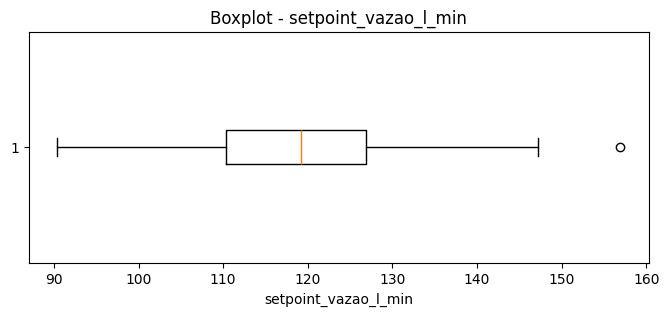

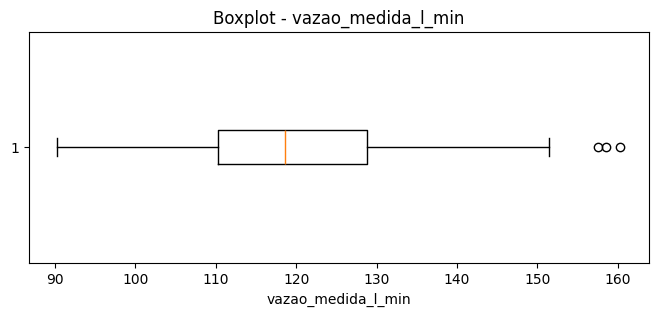

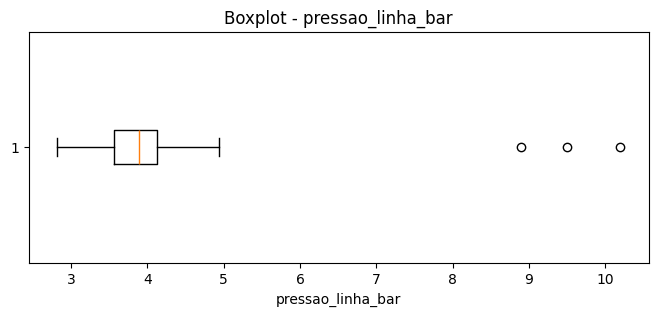

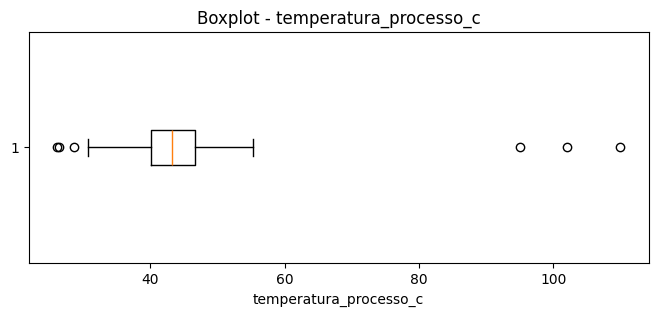

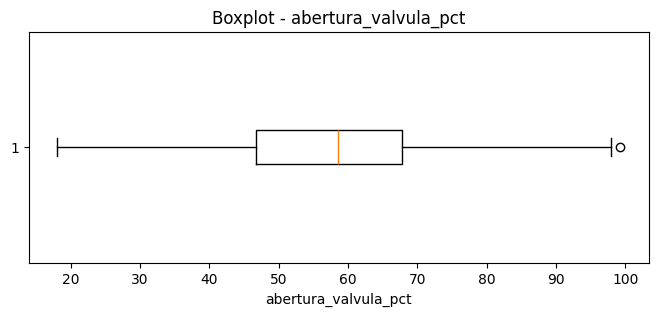

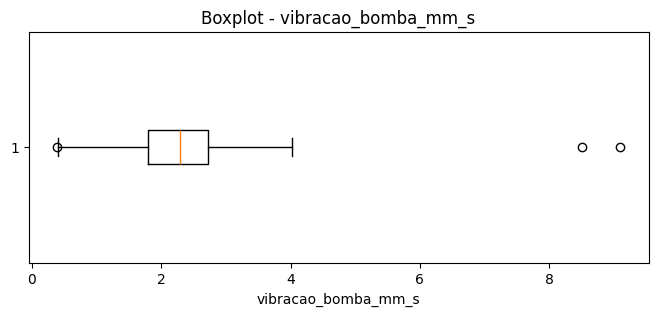

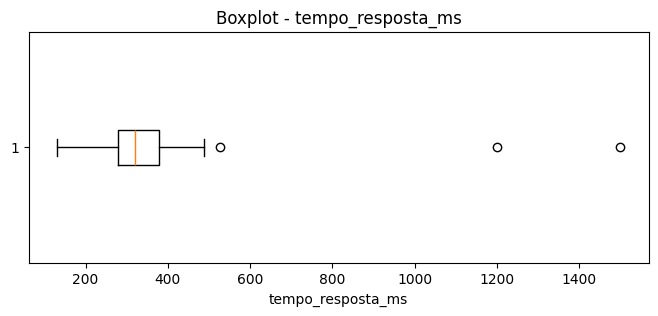

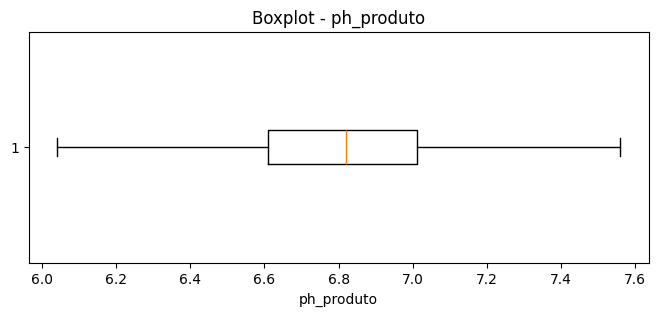

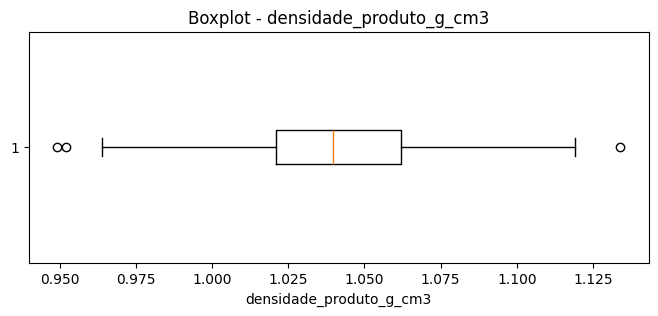

In [37]:
# Complete
# dica: crie uma lista com as colunas e use um laço para gerar os gráficos
# Definir lista de variáveis numéricas para análise
colunas_numericas = [
"setpoint_vazao_l_min",
"vazao_medida_l_min",
"pressao_linha_bar",
"temperatura_processo_c",
"abertura_valvula_pct",
"vibracao_bomba_mm_s",
"tempo_resposta_ms",
"ph_produto",
"densidade_produto_g_cm3"
]
print()
# Gerar boxplot para cada variável numérica
for coluna in colunas_numericas:
    plt.figure(figsize=(8, 3))
    plt.boxplot(df[coluna].dropna(), vert=False) # horizontal para melhor leitura
    plt.title(f"Boxplot - {coluna}")
    plt.xlabel(coluna)
    plt.show()

**Anotações do aluno sobre possíveis outliers:**  
- ______________________________________________  
- ______________________________________________  
- ______________________________________________


## 9. Correlação entre variáveis numéricas

Calcule a matriz de correlação.


In [38]:
# Complete
# Calcular a matriz de correlação entre variáveis numéricas
corr = df.select_dtypes(include=[np.number]).corr(numeric_only=True)
corr

,setpoint_vazao_l_min,vazao_medida_l_min,pressao_linha_bar,temperatura_processo_c,abertura_valvula_pct,vibracao_bomba_mm_s,tempo_resposta_ms,ph_produto,densidade_produto_g_cm3
setpoint_vazao_l_min,1.000000,0.801101,-0.091657,0.017862,0.054249,-0.131508,0.043946,0.159991,-0.031027
vazao_medida_l_min,0.801101,1.000000,0.012123,0.089933,0.068041,-0.070068,-0.036759,0.133953,-0.072082
pressao_linha_bar,-0.091657,0.012123,1.000000,-0.040471,-0.031933,-0.004311,-0.034882,-0.033072,0.071375
temperatura_processo_c,0.017862,0.089933,-0.040471,1.000000,-0.002120,0.057550,-0.016420,0.021347,-0.024445
abertura_valvula_pct,0.054249,0.068041,-0.031933,-0.002120,1.000000,-0.093294,-0.025390,-0.005975,-0.054070
vibracao_bomba_mm_s,-0.131508,-0.070068,-0.004311,0.057550,-0.093294,1.000000,-0.064778,-0.078114,-0.101135
tempo_resposta_ms,0.043946,-0.036759,-0.034882,-0.016420,-0.025390,-0.064778,1.000000,0.097510,0.027675
ph_produto,0.159991,0.133953,-0.033072,0.021347,-0.005975,-0.078114,0.097510,1.000000,0.001702
densidade_produto_g_cm3,-0.031027,-0.072082,0.071375,-0.024445,-0.054070,-0.101135,0.027675,0.001702,1.000000


## 10. Criação de uma variável auxiliar

Crie uma variável com o desvio absoluto entre:
- setpoint_vazao_l_min
- vazao_medida_l_min

Nome sugerido: `desvio_vazao_abs`


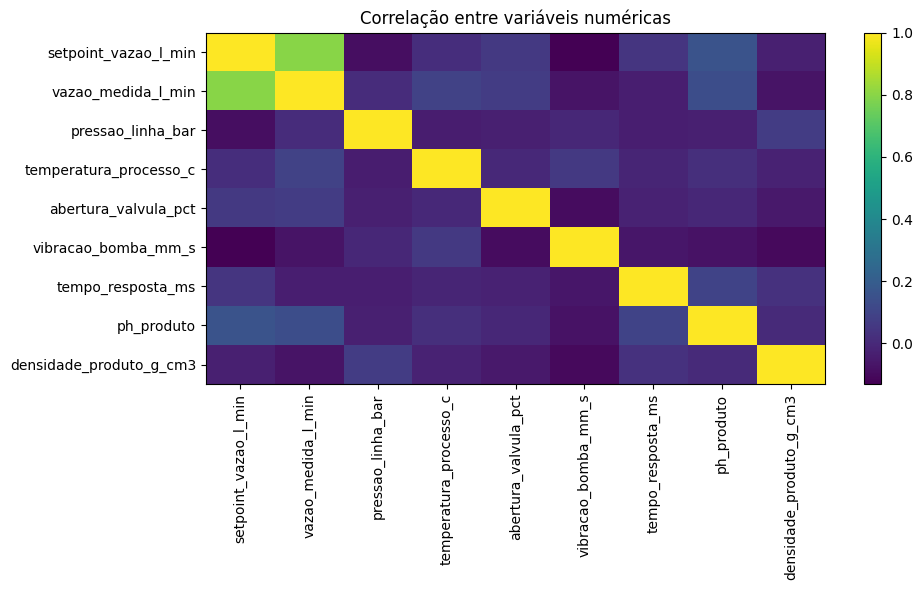

In [45]:
# Complete
# Visualizar como heatmap (mapa de calor)
plt.figure(figsize=(10, 6))
plt.imshow(corr, aspect="auto") # representação visual da matriz
plt.colorbar() # escala de cores
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()

In [51]:
# Criar variável auxiliar: desvio absoluto entre setpoint e medição real
df["desvio_vazao_abs"] = (df["setpoint_vazao_l_min"] - df["vazao_medida_l_min"]).abs()
# Visualizar resultado
df[["setpoint_vazao_l_min","vazao_medida_l_min", "desvio_vazao_abs"]].head()

,setpoint_vazao_l_min,vazao_medida_l_min,desvio_vazao_abs
0,121.44,128.08,6.64
1,126.17,119.32,6.85
2,128.54,129.11,0.57
3,106.50,102.68,3.82
4,101.59,NaN,NaN


## 11. Interpretação técnica

Responda com base na exploração realizada:

1. Quais problemas de qualidade de dados foram identificados?  
____________________________________________________________

2. Quais variáveis parecem críticas para avaliar a instrumentação?  
____________________________________________________________

3. Por que não devemos treinar um modelo imediatamente, sem inspeção?  
____________________________________________________________


## 12. Fechamento

Nesta aula, você começou a trabalhar o início do pipeline de Machine Learning:
- definição do problema;
- conhecimento da base;
- análise exploratória;
- identificação de problemas de qualidade.

Na próxima etapa, a base poderá ser tratada para uso em modelagem.
